In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import healpy as hp
import astropy.io.fits as fits

In [3]:
# The code in this notebook reproduces Figure 11 from Nofi et al. (2025a)
# https://arxiv.org/abs/2509.03718

In [4]:
nside=128

In [5]:
p143_map="HFI_SkyMap_143-field-IQU_2048_R3.00_full.fits"
p143=hp.fitsfunc.read_map(p143_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'BeamWf_HFI_R3.01/Bl_T_R3.01_fullsky_143x143.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[1].data  
p143_bl = tbdata['TEMPERATURE']
p143_ell = np.arange(0,len(p143_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p143_ell*(p143_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p143_bl
smth143_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 143 GHz beam window function
sm_r11_143 = hp.smoothing(p143, beam_window=smth143_kernel)

# Downgrade maps to NSIDE = 128
p143_dg = hp.ud_grade(sm_r11_143, nside)

# Convert to mK 
p143_dg = p143_dg * 1000

In [6]:
p100_map="HFI_SkyMap_100-field-IQU_2048_R3.00_full.fits"
p100=hp.fitsfunc.read_map(p100_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'BeamWf_HFI_R3.01/Bl_T_R3.01_fullsky_100x100.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[1].data  
p100_bl = tbdata['TEMPERATURE']
p100_ell = np.arange(0,len(p100_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p100_ell*(p100_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p100_bl
smth100_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 100 GHz beam window function
sm_r11_100 = hp.smoothing(p100, beam_window=smth100_kernel)

# Downgrade maps to NSIDE = 128
p100_dg = hp.ud_grade(sm_r11_100, nside)

# Convert to mK
p100_dg = p100_dg * 1000

In [7]:
p70_map="LFI_SkyMap_070-BPassCorrected-field-IQU_1024_R3.00_full.fits"
p70=hp.fitsfunc.read_map(p70_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'LFI_RIMO_R3.31.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[30].data  
p70_bl = tbdata['BL      ']
p70_ell = np.arange(0,len(p70_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p70_ell*(p70_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p70_bl
smth70_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 70 GHz beam window function
sm_r11_70 = hp.smoothing(p70, beam_window=smth70_kernel)

# Downgrade maps to NSIDE = 128
p70_dg = hp.ud_grade(sm_r11_70, nside)

# Convert to mK
p70_dg = p70_dg * 1000

In [8]:
# Map is already smoothed to 1 degree
wmapw_map="wmap_band_smth_imap_r9_9yr_W_v5.fits"
wmapw=hp.fitsfunc.read_map(wmapw_map,field=[0])

# Downgrade maps to NSIDE = 128
wmapw_dg = hp.ud_grade(wmapw, nside)

In [9]:
# Final cleaned maps (named 'ELC') from final cleaning fit (Section 3.6)
final_70_map="../ELC_Maps/ELC_70GHz.fits"
final_70=hp.fitsfunc.read_map(final_70_map,field=[0])

final_94_map="../ELC_Maps/ELC_94GHz.fits"
final_94=hp.fitsfunc.read_map(final_94_map,field=[0])

final_100_map="../ELC_Maps/ELC_100GHz.fits"
final_100=hp.fitsfunc.read_map(final_100_map,field=[0])

final_143_map="../ELC_Maps/ELC_143GHz.fits"
final_143=hp.fitsfunc.read_map(final_143_map,field=[0])

In [10]:
# 1% Mask (see Section 3.5)
mask="../ELC_Masks/ELC_1percent_mask.fits"
mask=hp.fitsfunc.read_map(mask,field=[0])

In [11]:
# Apply 1% Mask
p143_m = final_143 * mask
p100_m = final_100 * mask
w94_m = final_94 * mask
p70_m = final_70 * mask

In [12]:
# Change 0s to nans
p143_m[p143_m==0] = np.nan
p100_m[p100_m==0] = np.nan
w94_m[w94_m==0] = np.nan
p70_m[p70_m==0] = np.nan

In [13]:
best_stack = np.vstack((final_143, final_100, final_94, final_70))
stdv_map = np.std(best_stack, axis=0)

In [14]:
# Reverse of the 1% mask: "masked" pixels are now = 1 instead of 0 
reverse_std = 1-mask
reverse_std = reverse_std.astype(float)
reverse_std[reverse_std == 0] = np.nan

In [15]:
# Apply the reverse 1% mask to the raw frequency maps to determine which pixels are masked 
p143_mp = p143_dg * reverse_std
p100_mp = p100_dg * reverse_std
w94_mp= wmapw_dg*reverse_std
p70_mp = p70_dg * reverse_std

In [16]:
# Apply the reverse 1% mask to the cleaned final ELC maps to determine which pixels are masked 
p143_mp9 = final_143 * reverse_std
p100_mp9 = final_100 * reverse_std
w94_mp9= final_94 * reverse_std
p70_mp9 = final_70 * reverse_std

In [17]:
def galactic_to_range(l):
    'Converts Galactic longitude from [0, 360] range to [-180, 180] range for plotting'
    return np.where(l > 180, l - 360, l)

In [18]:
def pix_long_map(cmap, lat):
    'Returns pixels from input map at input Galactic latitude and sorted Galactic longitude'
    # Convert pixels to Galactic longitude and latitude
    glon, glat = hp.pix2ang(128, np.arange(len(cmap)), lonlat=True)
    
    # Select pixels at input latitude
    pmap = cmap[np.where(np.round((glat)) == lat)]
    glon = glon[np.where(np.round((glat)) == lat)]
    
    # Convert Galactic longitude from [0,360] to [-180,180]
    l_centered = galactic_to_range(glon)

    # Sort selected pixels by longitude
    sorted_indices = np.argsort(l_centered)
    # Longitude values
    l_sorted = l_centered[sorted_indices]
    # Map values
    map_sorted = pmap[sorted_indices]
    
    return map_sorted, l_sorted

In [19]:
# Looking at the pixels at glat = 0 degrees

# Full-sky raw 100 GHz map
map_sorted_100_0_r, l_sorted_100_0_r = pix_long_map(p100_dg, 0)

# Full-sky cleaned 100 GHz map
map_sorted_100_0_fs, l_sorted_100_0_fs = pix_long_map(final_100, 0)

# 1% mask cleaned 100 GHz map
map_sorted_100_0_m, l_sorted_100_0_m = pix_long_map(p100_m, 0)

# Reverse 1% mask raw 100 GHz map
# (this shows us the pixels at this glat that have been masked by 1% mask)
map_sorted_100_0_mpr, l_sorted_100_0_mpr = pix_long_map(p100_mp, 0)

# Reverse 1% cleaned 100 GHz map
# (this shows us the pixels at this glat that have been masked by 1% mask)
map_sorted_100_0_mp9, l_sorted_100_0_mp9 = pix_long_map(p100_mp9, 0)

In [20]:
# Looking at the pixels at glat = 2 degrees

# Full-sky raw 100 GHz map
map_sorted_100_2_r, l_sorted_100_2_r = pix_long_map(p100_dg, 2)

# Full-sky cleaned 100 GHz map
map_sorted_100_2_fs, l_sorted_100_2_fs = pix_long_map(final_100, 2)

# 1% mask cleaned 100 GHz map
map_sorted_100_2_m, l_sorted_100_2_m = pix_long_map(p100_m, 2)

# Reverse 1% mask raw 100 GHz map
# (this shows us the pixels at this glat that have been masked by 1% mask)
map_sorted_100_2_mpr, l_sorted_100_2_mpr = pix_long_map(p100_mp, 2)

# Reverse 1% cleaned 100 GHz map
# (this shows us the pixels at this glat that have been masked by 1% mask)
map_sorted_100_2_mp9, l_sorted_100_2_mp9 = pix_long_map(p100_mp9, 2)

In [21]:
# Looking at the pixels at glat = 5 degrees

# Full-sky raw 100 GHz map
map_sorted_100_5_r, l_sorted_100_5_r = pix_long_map(p100_dg, 5)

# Full-sky cleaned 100 GHz map
map_sorted_100_5_fs, l_sorted_100_5_fs = pix_long_map(final_100, 5)

# 1% mask cleaned 100 GHz map
map_sorted_100_5_m, l_sorted_100_5_m = pix_long_map(p100_m, 5)

# Reverse 1% mask raw 100 GHz map
# (this shows us the pixels at this glat that have been masked by 1% mask)
map_sorted_100_5_mpr, l_sorted_100_5_mpr = pix_long_map(p100_mp, 5)

# Reverse 1% cleaned 100 GHz map
# (this shows us the pixels at this glat that have been masked by 1% mask)
map_sorted_100_5_mp9, l_sorted_100_5_mp9 = pix_long_map(p100_mp9, 5)

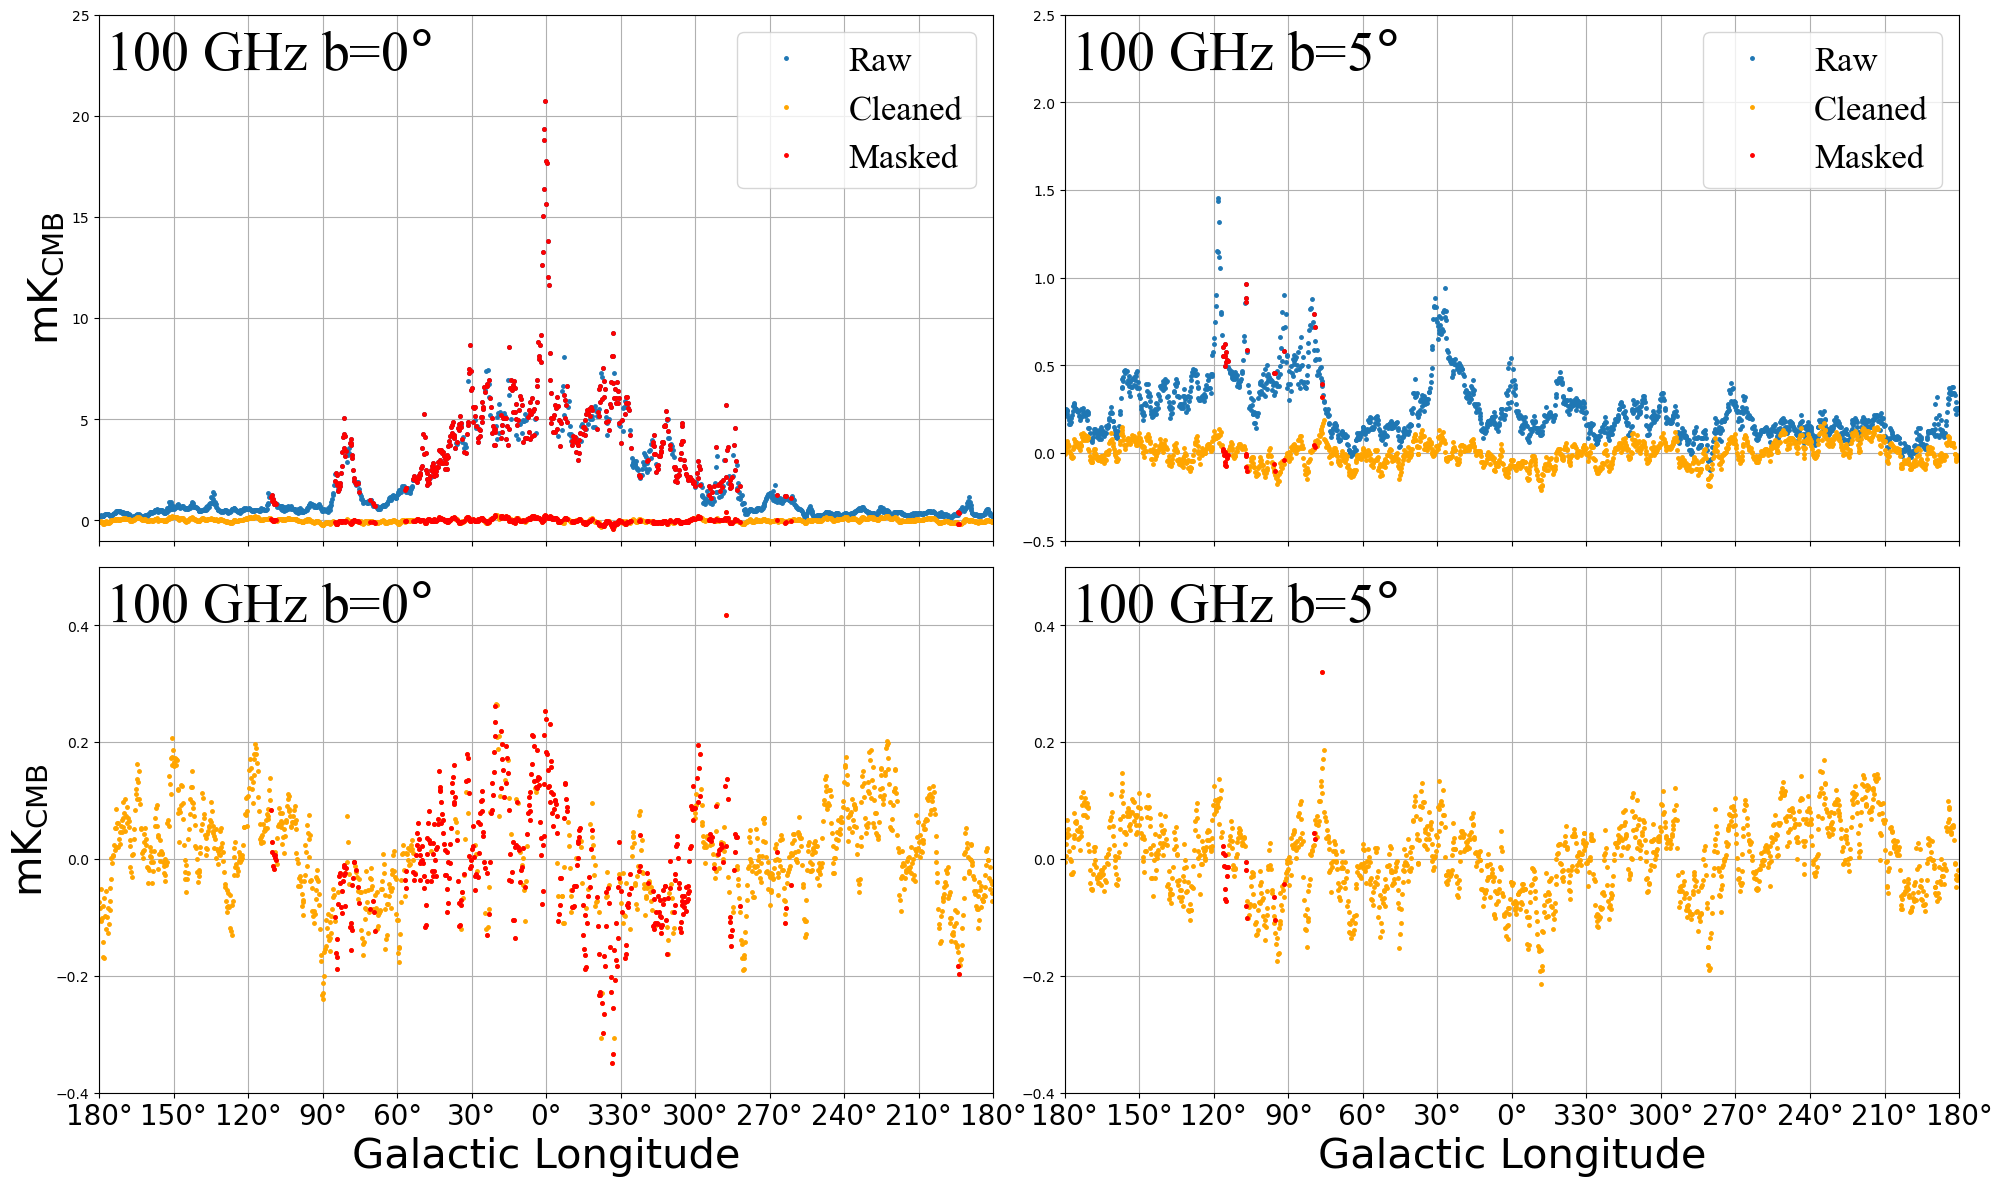

In [22]:
fig, axe = plt.subplots(2, 2, figsize=(24, 14), sharex=True,gridspec_kw={'hspace': 0.05, 'wspace': 0.08})
plt.rcParams.update({'font.size': 25})  
plt.rcParams['font.family'] = 'Times New Roman'

axe[0,0].plot(l_sorted_100_0_r, map_sorted_100_0_r, '.', markersize=5, label = 'Raw')
axe[0,0].plot(l_sorted_100_0_fs, map_sorted_100_0_fs, '.', markersize=5, color = 'orange', label = 'Cleaned')
axe[0,0].plot(l_sorted_100_0_mpr, map_sorted_100_0_mpr, '.', markersize=5, label = 'Masked', color='red')
axe[0,0].plot(l_sorted_100_0_mp9, map_sorted_100_0_mp9, '.', markersize=5, color='red')
axe[0,0].text(0.19, 0.97, '100 GHz b=0$\degree$', transform=axe[0,0].transAxes, fontsize=40, verticalalignment='top', horizontalalignment='center')
axe[0,0].set_ylabel(r'mK$_{\rm CMB}$', fontsize=30)
axe[0,0].legend(fontsize=25)
axe[0,0].set_ylim(-1,25)
axe[0,0].set_xlim(180, -180)
axe[0,0].grid(True)

axe[0,1].plot(l_sorted_100_5_r, map_sorted_100_5_r, '.', markersize=5, label = 'Raw')
axe[0,1].plot(l_sorted_100_5_fs, map_sorted_100_5_fs, '.', markersize=5, color = 'orange', label = 'Cleaned')
axe[0,1].plot(l_sorted_100_5_mpr, map_sorted_100_5_mpr, '.', markersize=5, label = 'Masked', color='red')
axe[0,1].plot(l_sorted_100_5_mp9, map_sorted_100_5_mp9, '.', markersize=5, color='red')
axe[0,1].text(0.19, 0.97, '100 GHz b=5$\degree$', transform=axe[0,1].transAxes, fontsize=40, verticalalignment='top', horizontalalignment='center')
axe[0,1].legend(fontsize=25)
axe[0,1].set_ylim(-0.5,2.5)
axe[0,1].set_xlim(180, -180)
axe[0,1].grid(True)


axe[1,0].plot(l_sorted_100_0_fs, map_sorted_100_0_fs, '.', markersize=5, color = 'orange', label = 'Cleaned')
axe[1,0].plot(l_sorted_100_0_mp9, map_sorted_100_0_mp9, '.', markersize=5, label = 'Masked', color='red')
axe[1,0].set_xlabel('Galactic Longitude', fontsize=30)
axe[1,0].text(0.19, 0.97, '100 GHz b=0$\degree$', transform=axe[1,0].transAxes, fontsize=40, verticalalignment='top', horizontalalignment='center')
axe[1,0].set_ylabel(r'mK$_{\rm CMB}$', fontsize=30)
axe[1,0].set_xlim(180, -180)  
axe[1,0].set_ylim(-0.4,0.5)
axe[1,0].grid(True)

axe[1,1].plot(l_sorted_100_5_fs, map_sorted_100_5_fs, '.', markersize=5, color = 'orange', label = 'Cleaned')
axe[1,1].plot(l_sorted_100_5_mp9, map_sorted_100_5_mp9, '.', markersize=5, label = 'Masked', color='red')
axe[1,1].set_xlabel('Galactic Longitude', fontsize=30)
axe[1,1].text(0.19, 0.97, '100 GHz b=5$\degree$', transform=axe[1,1].transAxes, fontsize=40, verticalalignment='top', horizontalalignment='center')
axe[1,1].set_xlim(180, -180)
axe[1,1].set_ylim(-0.4,0.5)
axe[1,1].grid(True)


ticks = np.linspace(180, -180, 13)
labels = ['180°', '150°', '120°', '90°', '60°', '30°', '0°', 
          '330°', '300°', '270°', '240°', '210°', '180°']
axe[1,1].set_xticks(ticks)
axe[1,1].set_xticklabels(labels,fontsize=20)
axe[1,0].set_xticks(ticks)
axe[1,0].set_xticklabels(labels,fontsize=20)

plt.show()

In [23]:
# Number of pixels masked at glat = 0 degrees
np.count_nonzero(~np.isnan(map_sorted_100_0_mp9))

438

In [24]:
# Number of pixels masked at glat = 2 degrees
np.count_nonzero(~np.isnan(map_sorted_100_2_mp9))

119

In [25]:
# Number of pixels masked at glat = 5 degrees
np.count_nonzero(~np.isnan(map_sorted_100_5_mp9))

20